In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from loader.dataset import DUNEImageDataset
from loader.apa_dataset import APAImageDataset
from loader.splits import train_val_split

## Test APASparseDataset

In [7]:
from loader.apa_sparse_dataset import APASparseDataset
from loader.collate import voxels_collate_fn

rootdir_sparse = "/nfs/data/1/yuhw/cffm-data/prod-jay-1M-2026-02-27-sample/13717/1/001/out_monte-carlo-013717-000001_310694_6_1_20260224T033536Z/"
rootdir_sparse = "/nfs/data/1/yuhw/cffm-data/prod-jay-1M-2026-02-27-sample/"

ds_sparse = APASparseDataset(
    rootdir=rootdir_sparse,
    apa=0,
    view="W",
    use_cache=True,
    cache_dir="./data",
)

print("Dataset size:", len(ds_sparse))

Cache does not exist: data/APASparseDataset_APA0_viewW_ac865669_cache.pt -- generating new one!
Saving dataset index to cache: data/APASparseDataset_APA0_viewW_ac865669_cache.pt
Dataset size: 210


In [8]:
idx = 1
vox = ds_sparse[idx]

print("Index:", idx)
print("vox:", vox)
print("Batch size:", vox.batch_size)
print("Num active voxels:", vox.coordinate_tensor.shape[0])
print("Num channels:", vox.num_channels)
print("coordinate_tensor:", vox.coordinate_tensor.shape, vox.coordinate_tensor.dtype)
print("feature_tensor:   ", vox.feature_tensor.shape,    vox.feature_tensor.dtype)
print("offsets:          ", vox.offsets)

Index: 1
vox: Voxels(feature_shape=torch.Size([4567, 1]), coords_shape=torch.Size([4567, 2]))
Batch size: 1
Num active voxels: 4567
Num channels: 1
coordinate_tensor: torch.Size([4567, 2]) torch.int32
feature_tensor:    torch.Size([4567, 1]) torch.float32
offsets:           tensor([   0, 4567])


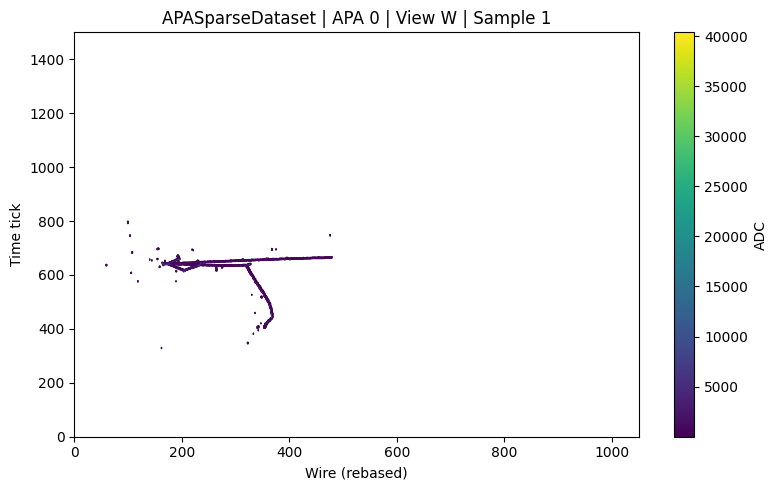

In [9]:
# Scatter plot of a single sparse sample
coords_np = vox.coordinate_tensor.cpu().numpy()
vals_np   = vox.feature_tensor.cpu().numpy()[:, 0]

ch_range = ds_sparse.ch_end - ds_sparse.ch_start

plt.figure(figsize=(8, 5))
plt.scatter(coords_np[:, 0], coords_np[:, 1], c=vals_np, s=1, cmap="viridis", linewidths=0)
plt.xlim(0, ch_range)
plt.ylim(0, 1500)
plt.xlabel("Wire (rebased)")
plt.ylabel("Time tick")
plt.title(f"APASparseDataset | APA {ds_sparse.apa} | View {ds_sparse.view} | Sample {idx}")
plt.colorbar(label="ADC")
plt.tight_layout()
plt.show()

### DataLoader with voxels_collate_fn

In [14]:
from torch.utils.data import DataLoader

loader = DataLoader(
    ds_sparse,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=voxels_collate_fn,
)

batch = next(iter(loader))

print("Batch type:", type(batch))
print("Batch size:", batch.batch_size)
print("Num active voxels (all items):", batch.coordinate_tensor.shape[0])
print("coordinate_tensor:", batch.coordinate_tensor.shape, batch.coordinate_tensor.dtype)
print("feature_tensor:   ", batch.feature_tensor.shape,    batch.feature_tensor.dtype)
print("offsets:          ", batch.offsets)

# sanity check: each offset difference equals the number of active voxels per sample
counts = batch.offsets[1:] - batch.offsets[:-1]
print("Active voxels per sample:", counts.tolist())

Batch type: <class 'warpconvnet.geometry.types.voxels.Voxels'>
Batch size: 4
Num active voxels (all items): 12441
coordinate_tensor: torch.Size([12441, 2]) torch.int32
feature_tensor:    torch.Size([12441, 1]) torch.float32
offsets:           tensor([    0,  3475,  6583, 10084, 12441])
Active voxels per sample: [3475, 3108, 3501, 2357]


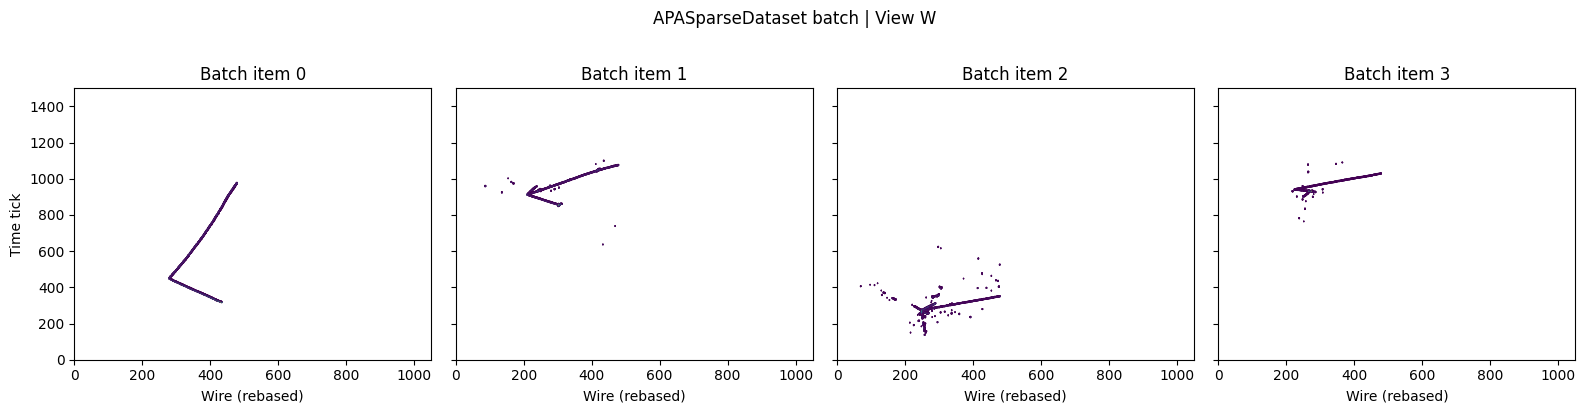

In [15]:
# Scatter plot of batched items, coloured by batch index
bic      = batch.batch_indexed_coordinates.cpu().numpy()  # (N_total, 3): (batch_idx, ch, tick)
vals_all = batch.feature_tensor.cpu().numpy()[:, 0]

ch_range = ds_sparse.ch_end - ds_sparse.ch_start

fig, axes = plt.subplots(1, batch.batch_size, figsize=(4 * batch.batch_size, 4), sharey=True)

for b, ax in enumerate(axes):
    mask = bic[:, 0] == b
    ax.scatter(bic[mask, 1], bic[mask, 2], c=vals_all[mask], s=1, cmap="viridis", linewidths=0)
    ax.set_xlim(0, ch_range)
    ax.set_ylim(0, 1500)
    ax.set_title(f"Batch item {b}")
    ax.set_xlabel("Wire (rebased)")

axes[0].set_ylabel("Time tick")
plt.suptitle(f"APASparseDataset batch | View {ds_sparse.view}", y=1.02)
plt.tight_layout()
plt.show()